# Analysis of S&P500 stocks: Financial Networks

In [23]:
'''Construction of dyanamic financial networks from stock price data, and analysis of their properties.'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import networkx as nx
from scipy.sparse.csgraph import minimum_spanning_tree

In [24]:
# Function to construct the minimum spanning tree graph from the distance matrix
def mst_graph(D: np.ndarray, stock_names: list[str]):
    mst_sparse = minimum_spanning_tree(D)
    mst_coo = mst_sparse.tocoo()

    G = nx.Graph()
    G.add_nodes_from(stock_names)

    for u, v, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):
        G.add_edge(stock_names[u], stock_names[v], weight=float(w), edge_type="mst")
    return G

# Function to construct the threshold graph from the correlation matrix
def threshold_graph(C: np.ndarray, stock_names: list[str], corr_threshold: float):
    G = nx.Graph()
    G.add_nodes_from(stock_names)

    n = C.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] >= corr_threshold:
                G.add_edge(stock_names[i], stock_names[j], weight=C[i, j], edge_type="threshold")
    return G

# Function to construct the combined graph with both MST and threshold edges
def mst_threshold_graph(C: np.ndarray, D: np.ndarray, stock_names: list[str], corr_threshold: float):
    G = mst_graph(D, stock_names)
    
    n = C.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] >= corr_threshold and not G.has_edge(stock_names[i], stock_names[j]):
                G.add_edge(stock_names[i], stock_names[j], weight=C[i, j], edge_type="threshold")
    return G

### Exploratory Data Analysis

In [25]:
df_price = pd.read_csv("data/SP500_AdjClose_Cleaned.csv")
df_price["Date"] = pd.to_datetime(df_price["Date"], format="%Y-%m-%d")

stock_cols = sorted([col for col in df_price.columns if col != "Date"], key=lambda x: x.split("_")[0])
df_price = df_price[["Date"] + stock_cols]

df_price.head()

,Date,CD_AMZN,CD_AZO,CD_BBY,CD_BKNG,CD_CCL,CD_DECK,CD_DRI,CD_DHI,CD_EBAY,...,UTL_NEE,UTL_NI,UTL_PCG,UTL_PEG,UTL_PNW,UTL_PPL,UTL_SO,UTL_SRE,UTL_WEC,UTL_XEL
0,2000-01-03,4.468750,30.5625,13.958043,301.860870,28.642263,0.145833,5.591213,2.616618,6.591352,...,2.242677,2.378940,11.473755,5.910198,9.416950,3.422152,4.231557,3.543866,4.081885,6.529201
1,2000-01-04,4.096875,30.4375,13.867408,318.058289,28.298550,0.140625,5.550847,2.517878,5.973049,...,2.283453,2.404250,11.980482,5.953575,9.535655,3.508911,4.278057,3.582246,4.108653,6.679542
2,2000-01-05,3.487500,30.3125,13.776765,353.029968,29.253307,0.142361,5.752693,2.554905,6.372612,...,2.358209,2.505480,12.776770,6.105400,9.792841,3.586028,4.498936,3.659009,4.296017,6.937274
3,2000-01-06,3.278125,29.0625,13.655912,338.673187,29.673395,0.154514,5.692140,2.419138,6.293866,...,2.358209,2.488608,12.885354,6.127087,9.852191,3.537827,4.510560,3.761361,4.282635,6.872839
4,2000-01-07,3.478125,30.4375,14.078887,337.200714,29.329681,0.149306,5.611400,2.505535,6.288032,...,2.426167,2.480172,12.885354,6.083711,10.129162,3.605309,4.591936,3.684598,4.336169,6.872839


In [26]:
df_logreturns = pd.DataFrame()
df_logreturns["Date"] = df_price["Date"]

for col in df_price.columns[1:]:
    df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))

df_logreturns = df_logreturns.dropna(how="any", axis=0).reset_index(drop=True)
df_logreturns.head()

C:\Users\Abbin\AppData\Local\Temp\ipykernel_21424\1989692367.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))
C:\Users\Abbin\AppData\Local\Temp\ipykernel_21424\1989692367.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))
C:\Users\Abbin\AppData\Local\Temp\ipykernel_21424\1989692367.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

,Date,CD_AMZN,CD_AZO,CD_BBY,CD_BKNG,CD_CCL,CD_DECK,CD_DRI,CD_DHI,CD_EBAY,...,UTL_NEE,UTL_NI,UTL_PCG,UTL_PEG,UTL_PNW,UTL_PPL,UTL_SO,UTL_SRE,UTL_WEC,UTL_XEL
0,2000-01-04,-0.086884,-0.004098,-0.006515,0.052268,-0.012073,-0.036365,-0.007246,-0.038466,-0.098501,...,0.018018,0.010583,0.043217,0.007313,0.012527,0.025036,0.010929,0.010772,0.006536,0.022765
1,2000-01-05,-0.161039,-0.004115,-0.006558,0.104318,0.033182,0.012269,0.035718,0.014599,0.064752,...,0.032214,0.041243,0.064350,0.025182,0.026614,0.021740,0.050342,0.021202,0.044593,0.037859
2,2000-01-06,-0.061914,-0.042111,-0.008811,-0.041517,0.014258,0.081919,-0.010582,-0.054604,-0.012434,...,0.000000,-0.006757,0.008463,0.003546,0.006042,-0.013532,0.002580,0.027589,-0.003120,-0.009332
3,2000-01-07,0.059222,0.046227,0.030504,-0.004357,-0.011651,-0.034287,-0.014286,0.035091,-0.000927,...,0.028410,-0.003395,0.000000,-0.007105,0.027725,0.018895,0.017880,-0.020619,0.012423,0.000000
4,2000-01-10,-0.005405,0.008180,-0.010788,-0.053825,0.043319,-0.072323,0.007169,0.019513,0.054165,...,-0.008438,0.023531,-0.019859,-0.001784,-0.013766,-0.010754,-0.007624,-0.010471,0.000000,0.000000


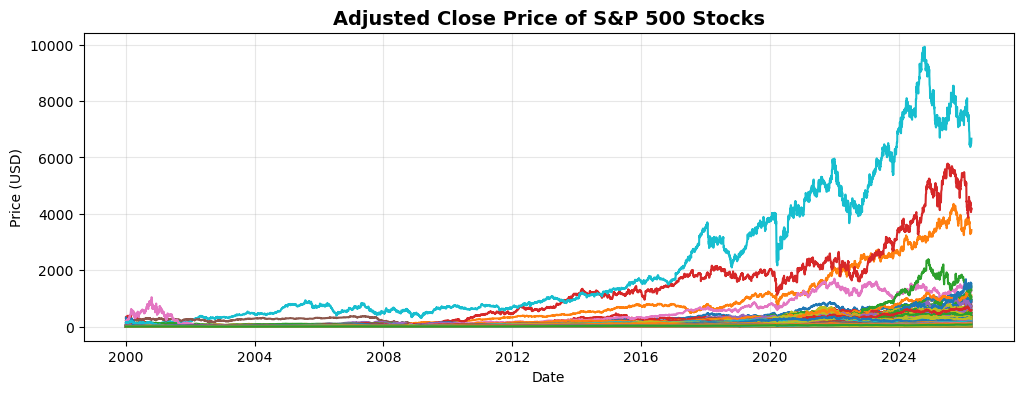

In [27]:
plt.figure(figsize=(12, 4))

for col in df_price.columns[1:]:
    plt.plot(df_price["Date"], df_price[col], label=col)

plt.title("Adjusted Close Price of S&P 500 Stocks", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.savefig("images/fig1_prices_sp500.png", bbox_inches="tight")
plt.show()

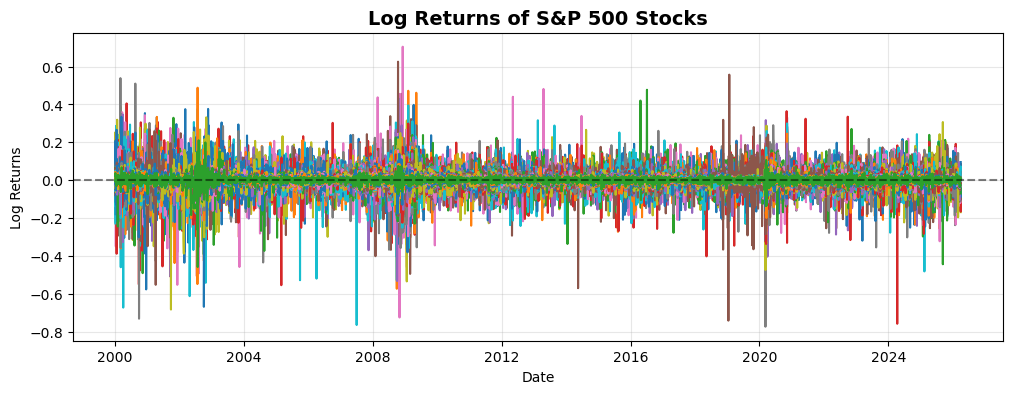

In [28]:
plt.figure(figsize=(12, 4))

for col in df_logreturns.columns[1:]:
    plt.plot(df_logreturns["Date"], df_logreturns[col], label=col)

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Log Returns of S&P 500 Stocks", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.grid(True, alpha=0.3)
plt.savefig("images/fig2_logreturns_sp500.png", bbox_inches="tight")
plt.show()

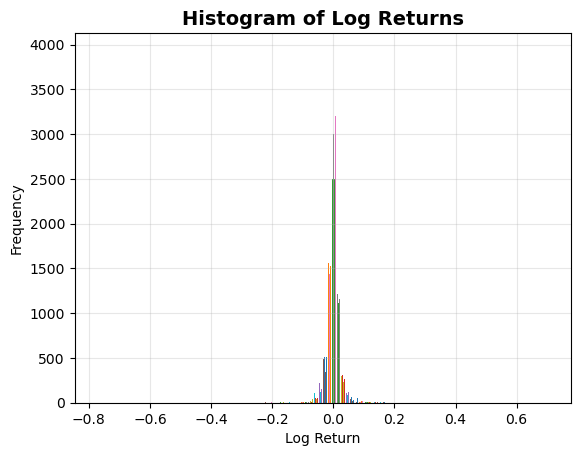

In [29]:
plt.hist(df_logreturns.iloc[:, 1:], bins=100, label=df_logreturns.columns[1:])
plt.title("Histogram of Log Returns", fontsize=14, fontweight="bold")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### Global Relationship (2000 - 2026)

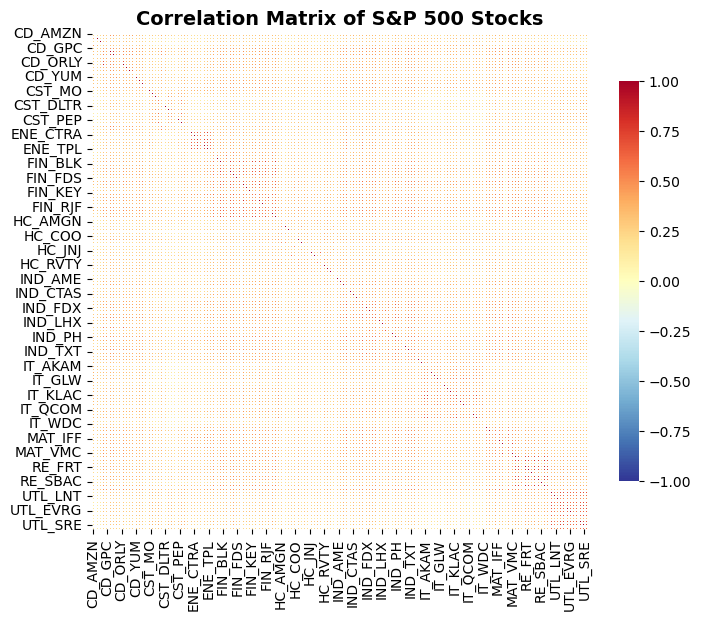

In [30]:
correlation_matrix = df_logreturns.iloc[:, 1:].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(correlation_matrix, fmt=".2f", cmap="RdYlBu_r", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title("Correlation Matrix of S&P 500 Stocks", fontsize=14, fontweight="bold")
plt.savefig("images/fig3_corr_heatmap_sp500.png", bbox_inches="tight")
plt.show()

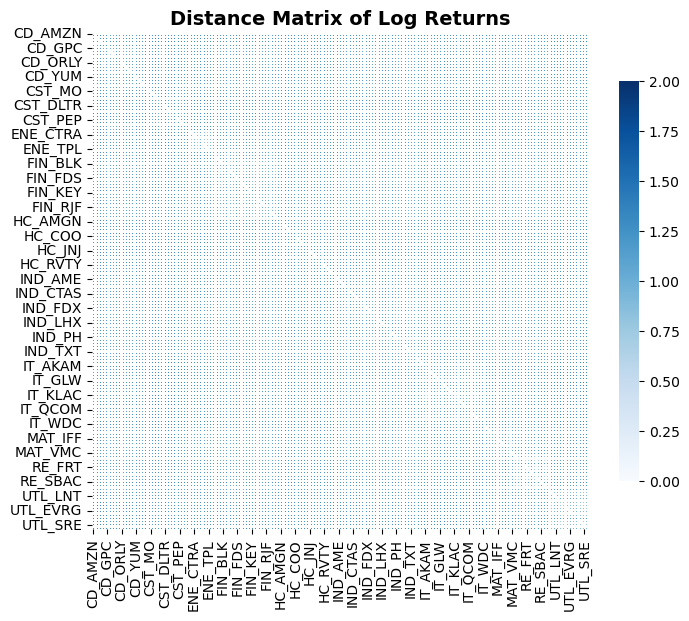

In [31]:
distance_matrix = np.sqrt(2 * (1 - correlation_matrix))

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(distance_matrix, fmt=".2f", cmap="Blues", vmin=0, vmax=2, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,)
plt.title("Distance Matrix of Log Returns", fontsize=14, fontweight="bold")
plt.show()

C:\Users\Abbin\AppData\Local\Temp\ipykernel_21424\1712955242.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_sector_names))


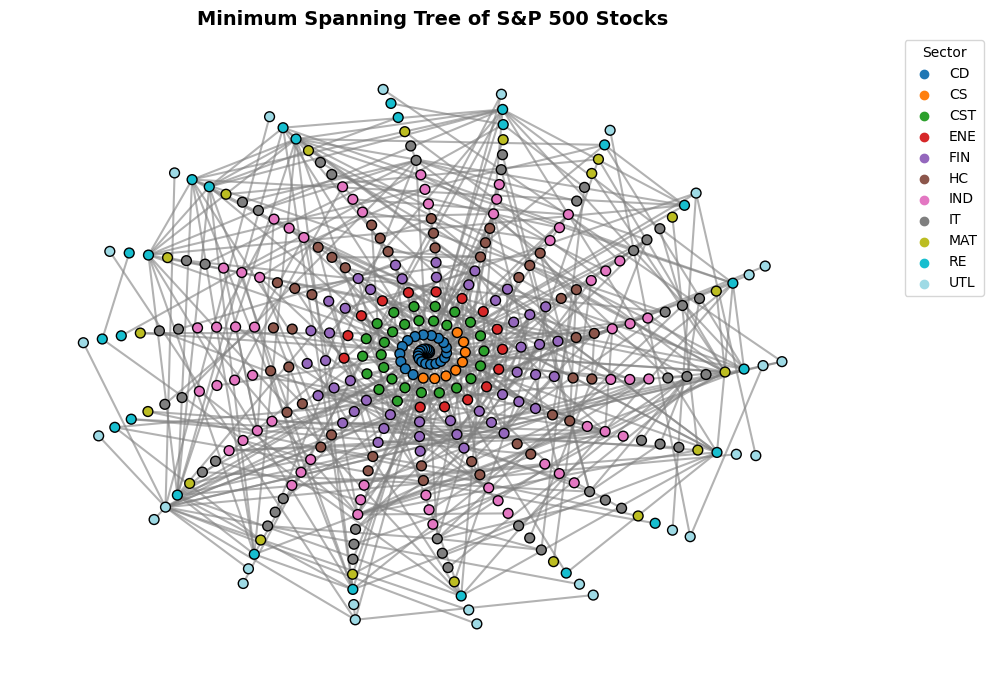

In [32]:
global_mst = mst_threshold_graph(correlation_matrix.values, distance_matrix.values, df_logreturns.columns[1:].tolist(), corr_threshold=0.75)

sector_map = {ticker: ticker.split("_")[0] for ticker in global_mst.nodes()}
unique_sector_names = sorted(set(sector_map.values()))

cmap = cm.get_cmap('tab20', len(unique_sector_names))
sector_color = {sector: cmap(i) for i, sector in enumerate(unique_sector_names)}
node_colors = [sector_color[sector_map[node]] for node in global_mst.nodes()]

pos = nx.spiral_layout(global_mst)
plt.figure(figsize=(10, 7))

nx.draw_networkx_edges(global_mst, pos, edge_color="gray", alpha=0.6, width=1.5)
nx.draw_networkx_nodes(global_mst, pos, node_color=node_colors, node_size=50, edgecolors="black", linewidths=1)
plt.title("Minimum Spanning Tree of S&P 500 Stocks", fontsize=14, fontweight="bold")
plt.axis("off")

for sector, color in sector_color.items():
    plt.scatter([], [], color=color, label=sector)

plt.legend(title="Sector", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("images/fig4_mst_sp500.png", dpi=200, bbox_inches="tight")
plt.show()

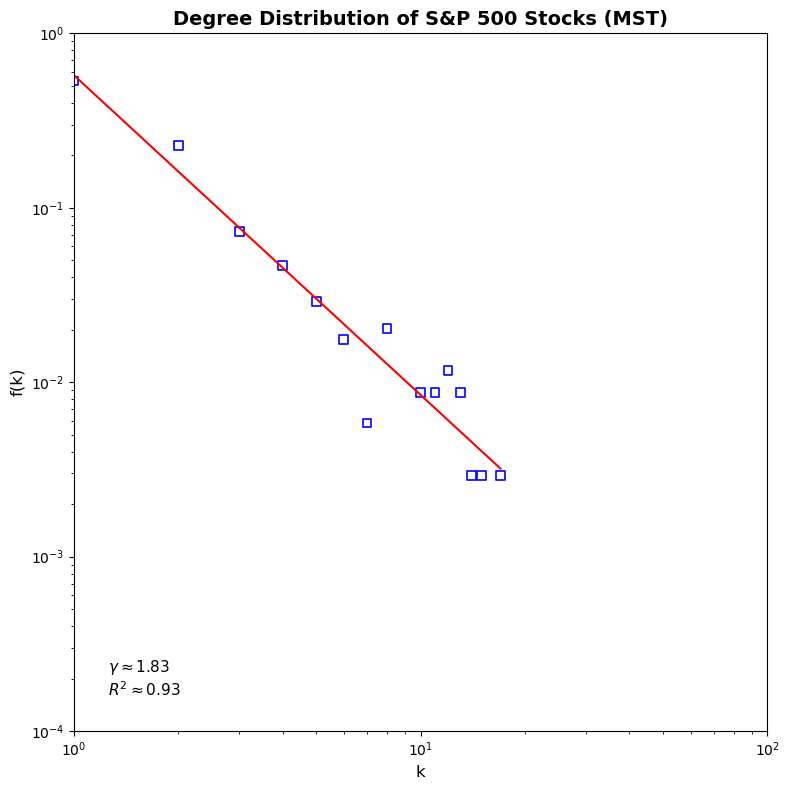

Estimated γ ≈ 1.83, R² ≈ 0.93


In [33]:
degree_distribution = [degree for node, degree in global_mst.degree()]
unique_degrees, counts = np.unique(degree_distribution, return_counts=True)
probabilities = counts / counts.sum()

k = unique_degrees
f_k = probabilities
log_k = np.log10(k)
log_f = np.log10(f_k)

coeffs = np.polyfit(log_k, log_f, 1)
slope, intercept = coeffs
gamma = -slope

k_fit = np.linspace(min(k), max(k), 100)
f_fit = 10**intercept * k_fit**slope

log_f_pred = slope * log_k + intercept
ss_res = np.sum((log_f - log_f_pred)**2)
ss_tot = np.sum((log_f - np.mean(log_f))**2)
r2 = 1 - ss_res / ss_tot

plt.figure(figsize=(8, 8))
plt.scatter(k, f_k, facecolors='none', edgecolors='blue', marker='s', s=40, linewidths=1.2)
plt.plot(k_fit, f_fit, color='red', linewidth=1.5)
plt.xscale("log")
plt.yscale("log")
plt.xlim(10**0, 10**2)
plt.ylim(10**-4, 10**0)
plt.title("Degree Distribution of S&P 500 Stocks (MST)", fontsize=14, fontweight="bold")
plt.xlabel("k", fontsize=12)
plt.ylabel("f(k)", fontsize=12)
plt.text(0.05, 0.05, f"$\\gamma \\approx {gamma:.2f}$\n$R^2 \\approx {r2:.2f}$", transform=plt.gca().transAxes, fontsize=11)
plt.savefig("images/fig5_degree_dist_mst_sp500.png", dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Estimated γ ≈ {gamma:.2f}, R² ≈ {r2:.2f}")

### Local Relationship (epoch_length = 40, epoch_shift = 20)

In [34]:
epoch_length = 40
epoch_shift = 20

stock_names = df_logreturns.columns[1:].tolist()

correlation_matrices = []
distance_matrices = []
mu_values = []
epoch_dates = []

for i in range(0, len(df_logreturns) - epoch_length, epoch_shift):
  epoch = df_logreturns.iloc[i:i+epoch_length]

  correlation_matrix = epoch.iloc[:, 1:].corr().values
  distance_matrix = np.sqrt(2 * (1 - correlation_matrix))
  mu = np.mean(correlation_matrix)

  correlation_matrices.append(correlation_matrix)
  distance_matrices.append(distance_matrix)
  mu_values.append(mu)

  epoch_dates.append(epoch["Date"].iloc[-1])

print(len(correlation_matrices))

328


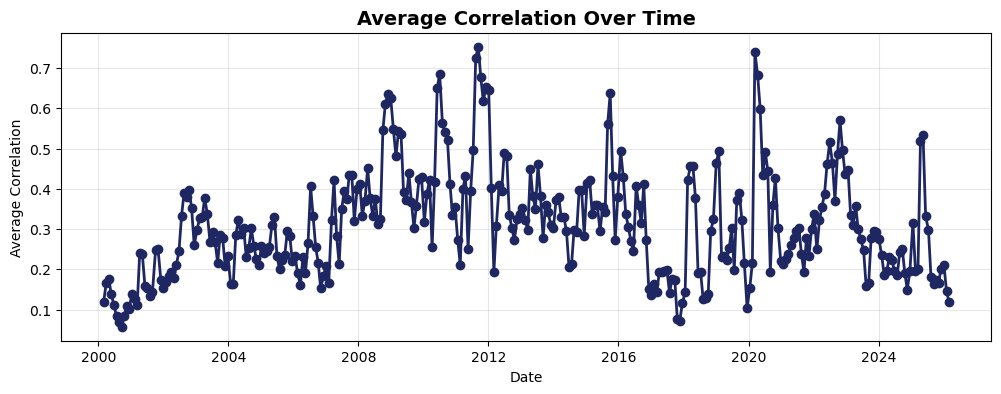

In [35]:
plt.figure(figsize=(12, 4))
plt.plot(epoch_dates, mu_values, color="#1E2761", label="Average Correlation", marker="o", linewidth=2)
plt.title("Average Correlation Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.grid(True, alpha=0.3)
plt.savefig("images/fig6_avg_corr_sp500.png", dpi=200, bbox_inches="tight")
plt.show()